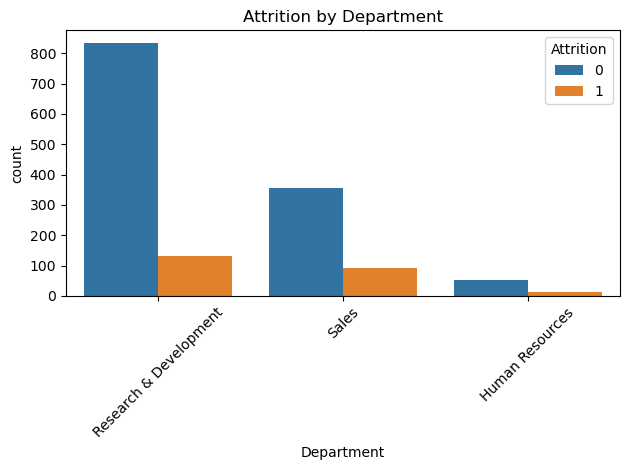

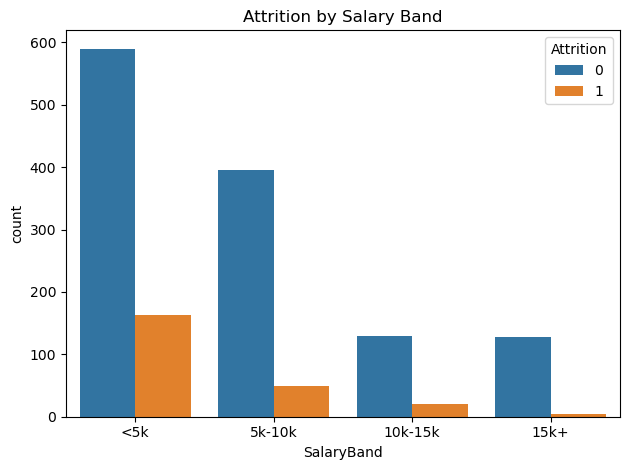

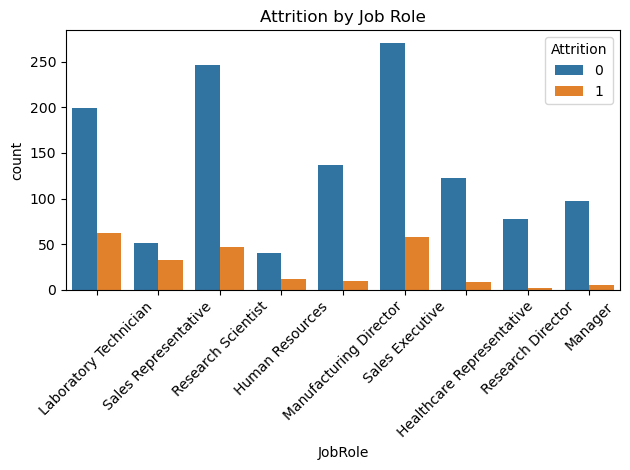

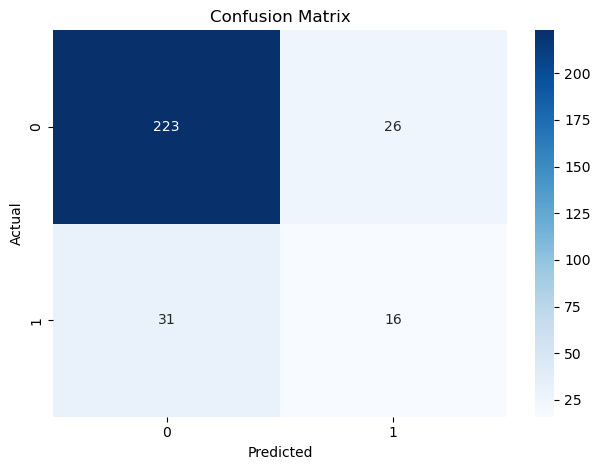

shap_values[1].shape: (1526, 2)
X_test_np.shape: (296, 1526)


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import shap
import numpy as np

# Load and preprocess
df = pd.read_csv("HR_Analytics.csv")
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])

df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 5000, 10000, 15000, df['MonthlyIncome'].max()],
    labels=['<5k', '5k-10k', '10k-15k', '15k+']
)

# Convert SalaryBand to dummies BEFORE modeling
salary_dummies = pd.get_dummies(df['SalaryBand'], prefix='SalaryBand', drop_first=True)

# Drop EmployeeNumber and SalaryBand from df, join dummy variables
df_model = df.drop(['EmployeeNumber', 'SalaryBand'], axis=1).join(salary_dummies)

# Get dummies for all remaining categorical variables except Attrition
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Plots (unchanged)
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sns.countplot(data=df, x='SalaryBand', hue='Attrition')
plt.title('Attrition by Salary Band')
plt.tight_layout()
plt.show()

sns.countplot(data=df, x='JobRole', hue='Attrition')
plt.title('Attrition by Job Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# --- SHAP explanation ---

# Convert X_test to numpy array for SHAP
X_test_np = X_test.values

# Use TreeExplainer for sklearn decision tree
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_np)

# shap_values is a list for binary classification: shap_values[0], shap_values[1]
# Check shapes:
print(f"shap_values[1].shape: {shap_values[1].shape}")
print(f"X_test_np.shape: {X_test_np.shape}")

# If they mismatch, try dropping last column if it exists (common cause)
if shap_values[1].shape[1] == X_test_np.shape[1] + 1:
    shap_vals = shap_values[1][:, :-1]  # drop last column
else:
    shap_vals = shap_values[1]



